# Modelagem — Previsão de Inadimplência

Este notebook constrói, avalia e compara modelos de previsão de inadimplência a partir das features desenvolvidas em `src/feature_engineering.py`.

Estrutura:
1. Preparação dos dados (features, alvo, split temporal)
2. Estratégia de tratamento de nulos
3. Baseline — Regressão Logística
4. LightGBM (baseline e com tuning via Optuna)
5. Avaliação final do melhor modelo (importância de variáveis e calibração)
6. Conclusões

In [1]:
import sys
sys.path.append("..")

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, log_loss
from scipy.stats import ks_2samp

import lightgbm as lgb
import optuna

from src.feature_engineering import build_features, read_csv_semicolon

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

RANDOM_STATE = 42
DATA_DIR = "../data"


## 1. Preparação dos Dados

### 1.1 Carregamento e geração de features

Carregamos as bases (`sep=";"`) e aplicamos `build_features` ao conjunto de desenvolvimento, usando-o simultaneamente como fonte de histórico e como alvo (cada linha usa apenas safras anteriores à sua própria safra — ver notebook `02_feature_engineering.ipynb` para a validação de que isso não gera vazamento de dados).

In [2]:
df_cadastral = read_csv_semicolon(f"{DATA_DIR}/base_cadastral.csv")
df_info = read_csv_semicolon(f"{DATA_DIR}/base_info.csv")
df_pag_dev = read_csv_semicolon(f"{DATA_DIR}/base_pagamentos_desenvolvimento.csv")

feat_dev = build_features(df_cadastral, df_info, df_pag_dev, df_pag_dev)
print("Shape das features:", feat_dev.shape)
feat_dev.head()

Shape das features: (77414, 25)


,ID_CLIENTE,SAFRA_REF,flag_pf,porte_encoded,segmento_freq,dominio_freq,cep_freq,ddd_freq,meses_desde_cadastro,renda_mes_anterior,no_funcionarios,qtd_pagamentos_anteriores,qtd_inadimplencias_anteriores,flag_cliente_novo,taxa_inadimplencia_hist,media_atraso_dias,std_atraso_dias,max_atraso_dias,valor_medio_hist,taxa_media_hist,valor_a_pagar,taxa,dia_vencimento,dias_emissao_vencimento,ratio_valor_renda
0,1661240395903230676,2018-08,0,0,0.408279,0.305058,0.01749,0.007421,60,NaN,NaN,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,35516.41,6.99,6,20,NaN
1,1661240395903230676,2018-08,0,0,0.408279,0.305058,0.01749,0.007421,60,NaN,NaN,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,17758.21,6.99,10,22,NaN
2,1661240395903230676,2018-08,0,0,0.408279,0.305058,0.01749,0.007421,60,NaN,NaN,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,17431.96,6.99,17,22,NaN
3,1661240395903230676,2018-08,0,0,0.408279,0.305058,0.01749,0.007421,60,NaN,NaN,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,1341.00,6.99,5,36,NaN
4,1661240395903230676,2018-08,0,0,0.408279,0.305058,0.01749,0.007421,60,NaN,NaN,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,21309.85,6.99,20,20,NaN


### 1.2 Construção da variável-alvo

Aplicamos a mesma regra de negócio definida no EDA: `inadimplente = 1` se `dias_atraso >= 5` ou se não há `DATA_PAGAMENTO` registrado.

In [3]:
df_pag_dev_y = df_pag_dev.copy()
df_pag_dev_y["DATA_PAGAMENTO"] = pd.to_datetime(df_pag_dev_y["DATA_PAGAMENTO"])
df_pag_dev_y["DATA_VENCIMENTO"] = pd.to_datetime(df_pag_dev_y["DATA_VENCIMENTO"])
dias_atraso = (df_pag_dev_y["DATA_PAGAMENTO"] - df_pag_dev_y["DATA_VENCIMENTO"]).dt.days
y = ((dias_atraso >= 5) | df_pag_dev_y["DATA_PAGAMENTO"].isna()).astype(int)
y.index = feat_dev.index

print(f"Taxa de inadimplência geral: {y.mean()*100:.2f}%")

Taxa de inadimplência geral: 7.02%


### 1.3 Split temporal (out-of-time)

Usamos safras mais antigas para treino e as safras mais recentes para validação, em vez de um split aleatório. Isso é importante por dois motivos:

1. **Realismo do cenário de produção.** Na prática, o modelo é treinado com o histórico disponível até um certo momento e usado para prever cobranças *futuras* — exatamente a situação que reproduzimos com a base de teste (safras posteriores às de desenvolvimento). Um split aleatório misturaria períodos passados e futuros dentro do treino, gerando uma estimativa de performance otimista demais e não representativa do uso real.
2. **Mudança de comportamento ao longo do tempo.** A EDA mostrou que a taxa de inadimplência varia por safra. Um split aleatório permitiria que o modelo "visse" padrões de safras estatisticamente parecidas com as de validação durante o treino, mascarando problemas de *drift* que só um split temporal consegue expor.

Escolhemos como corte a safra `2021-01`, com base na distribuição acumulada de volume por safra (ver EDA): isso deixa aproximadamente 82% das linhas para treino e 18% (as últimas 6 safras, `2021-01` a `2021-06`) para validação — um tamanho de validação razoável e imediatamente anterior ao início da base de teste (`2021-07`).

In [4]:
VAL_START_SAFRA = "2021-01"

train_mask = feat_dev["SAFRA_REF"] < VAL_START_SAFRA
val_mask = feat_dev["SAFRA_REF"] >= VAL_START_SAFRA

FEATURE_COLS = [c for c in feat_dev.columns if c not in ("ID_CLIENTE", "SAFRA_REF")]

X_train, X_val = feat_dev.loc[train_mask, FEATURE_COLS], feat_dev.loc[val_mask, FEATURE_COLS]
y_train, y_val = y[train_mask], y[val_mask]

def fmt_int_br(n):
    return f"{n:,}".replace(",", ".")


print(f"Treino: {fmt_int_br(X_train.shape[0])} linhas ({train_mask.mean()*100:.1f}%), safras {feat_dev.loc[train_mask, 'SAFRA_REF'].min()} a {feat_dev.loc[train_mask, 'SAFRA_REF'].max()}")
print(f"Validação: {fmt_int_br(X_val.shape[0])} linhas ({val_mask.mean()*100:.1f}%), safras {feat_dev.loc[val_mask, 'SAFRA_REF'].min()} a {feat_dev.loc[val_mask, 'SAFRA_REF'].max()}")

Treino: 63.147 linhas (81.6%), safras 2018-08 a 2020-12
Validação: 14.267 linhas (18.4%), safras 2021-01 a 2021-06


### 1.4 Distribuição do alvo em treino e validação

,treino,validacao
taxa_inadimplencia_%,7.18799,6.287236
n_inadimplentes,4539.00000,897.000000
n_total,63147.00000,14267.000000


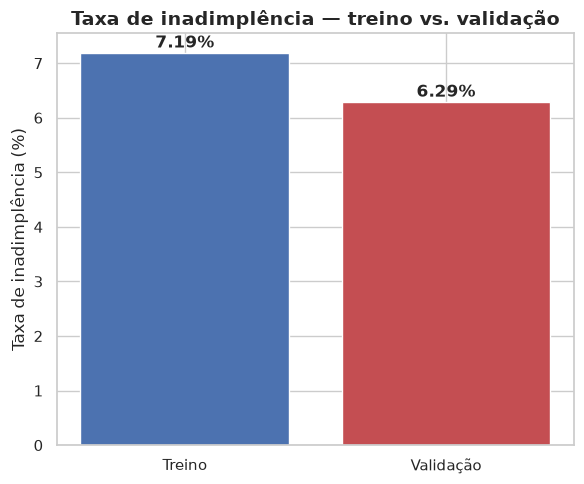

In [5]:
dist_table = pd.DataFrame(
    {
        "treino": [y_train.mean() * 100, (y_train == 1).sum(), len(y_train)],
        "validacao": [y_val.mean() * 100, (y_val == 1).sum(), len(y_val)],
    },
    index=["taxa_inadimplencia_%", "n_inadimplentes", "n_total"],
)
display(dist_table)

fig, ax = plt.subplots(figsize=(6, 5))
rates = [y_train.mean() * 100, y_val.mean() * 100]
ax.bar(["Treino", "Validação"], rates, color=["#4C72B0", "#C44E52"])
for i, v in enumerate(rates):
    ax.text(i, v + 0.1, f"{v:.2f}%", ha="center", fontweight="bold")
ax.set_title("Taxa de inadimplência — treino vs. validação")
ax.set_ylabel("Taxa de inadimplência (%)")
plt.tight_layout()
plt.show()

## 2. Estratégia de Tratamento de Nulos

Adotamos estratégias diferentes por modelo, de acordo com sua natureza:

- **LightGBM (e modelos baseados em árvore em geral):** mantemos os nulos como estão. O LightGBM trata valores ausentes nativamente — durante o treinamento, para cada split, ele aprende a direção (esquerda ou direita) que minimiza a perda para as observações com valor ausente naquela variável, em vez de exigir uma imputação arbitrária. Isso evita introduzir viés de uma imputação genérica e preserva o sinal informativo de "a variável está ausente" (relevante aqui, já que nulos em `renda_mes_anterior`/`no_funcionarios` e nas features comportamentais têm significado — ausência de informação cadastral ou cliente novo, respectivamente).
- **Regressão Logística (baseline linear):** como é um modelo linear que não lida com `NaN`, imputamos com a **mediana** de cada variável (`SimpleImputer(strategy="median")`), por ser robusta a outliers — a EDA mostrou caudas pesadas em variáveis como `valor_a_pagar` e nas estatísticas de atraso, o que tornaria a média sensível a valores extremos.

## 3. Baseline — Regressão Logística

Treinamos uma Regressão Logística com imputação por mediana + padronização (`StandardScaler`, necessária pois a Regressão Logística é sensível à escala das variáveis). Usamos `class_weight="balanced"` para compensar o desbalanceamento da classe positiva (~7% de inadimplência).

In [6]:
# AUC-ROC, estatistica KS (distancia maxima entre as CDFs dos scores das duas classes) e Log Loss.
def compute_metrics(y_true, y_proba):
    auc = roc_auc_score(y_true, y_proba)
    ks = ks_2samp(y_proba[y_true == 1], y_proba[y_true == 0]).statistic
    ll = log_loss(y_true, y_proba)
    return {"AUC-ROC": auc, "KS": ks, "LogLoss": ll}


# curves: list of (label, y_true, y_proba) tuples.
def plot_roc(curves, title):
    fig, ax = plt.subplots(figsize=(7, 7))
    for label, y_true, y_proba in curves:
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        auc = roc_auc_score(y_true, y_proba)
        ax.plot(fpr, tpr, linewidth=2, label=f"{label} (AUC = {auc:.3f})")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatório (AUC = 0.5)")
    ax.set_xlabel("Taxa de Falsos Positivos")
    ax.set_ylabel("Taxa de Verdadeiros Positivos")
    ax.set_title(title)
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


results = {}

In [7]:
lr_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]
)
lr_pipeline.fit(X_train, y_train)

proba_lr = lr_pipeline.predict_proba(X_val)[:, 1]
results["Regressão Logística"] = compute_metrics(y_val, proba_lr)
pd.DataFrame(results).T

,AUC-ROC,KS,LogLoss
Regressão Logística,0.896722,0.673091,0.449973


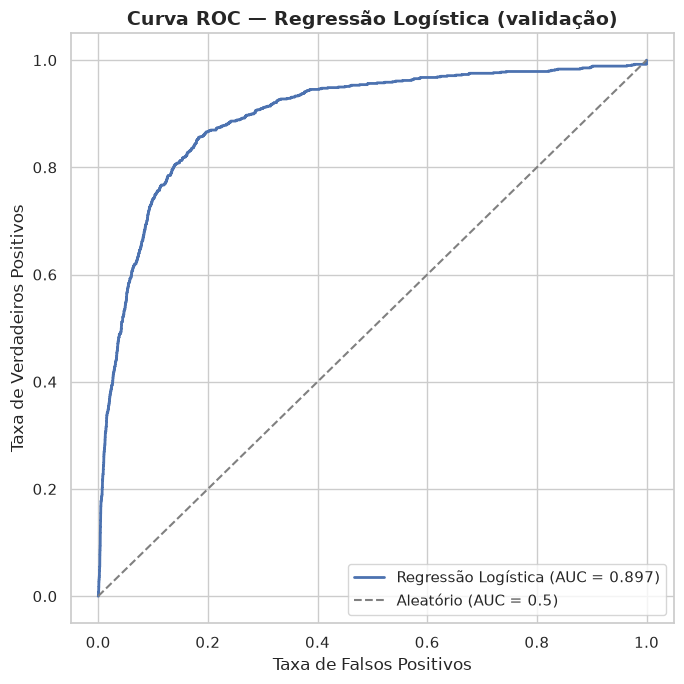

In [8]:
plot_roc([("Regressão Logística", y_val, proba_lr)], "Curva ROC — Regressão Logística (validação)")

## 4. LightGBM

### 4.1 Modelo com hiperparâmetros iniciais

Treinamos um `LGBMClassifier` com hiperparâmetros iniciais razoáveis: número moderado de folhas (`num_leaves=31`, o padrão da biblioteca), `learning_rate=0.05` e `n_estimators=300`. Usamos `is_unbalance=True` para que o LightGBM compense automaticamente o desbalanceamento de classes (alternativa equivalente seria definir `scale_pos_weight` manualmente como a razão entre negativos e positivos).

In [9]:
lgbm_baseline = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    is_unbalance=True,
    random_state=RANDOM_STATE,
    verbose=-1,
)
lgbm_baseline.fit(X_train, y_train)

proba_lgbm_baseline = lgbm_baseline.predict_proba(X_val)[:, 1]
results["LightGBM (baseline)"] = compute_metrics(y_val, proba_lgbm_baseline)
pd.DataFrame(results).T

,AUC-ROC,KS,LogLoss
Regressão Logística,0.896722,0.673091,0.449973
LightGBM (baseline),0.946544,0.780354,0.203780


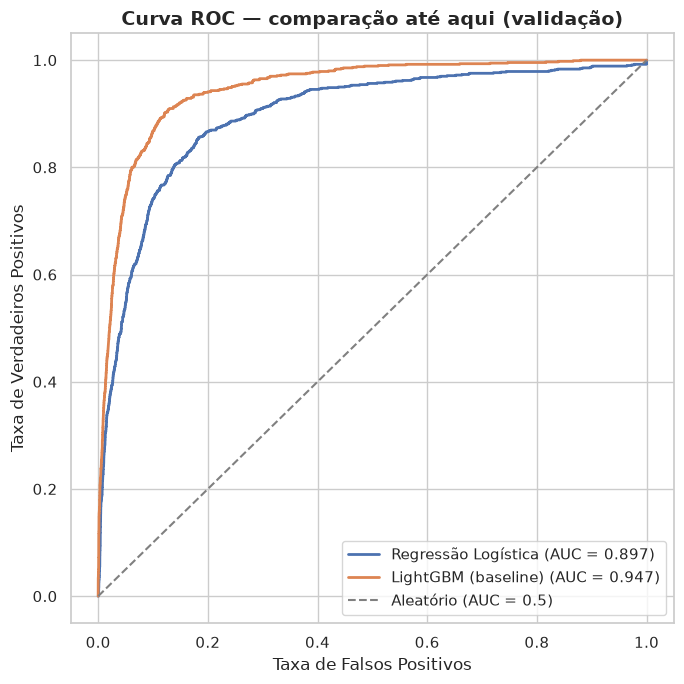

In [10]:
plot_roc(
    [
        ("Regressão Logística", y_val, proba_lr),
        ("LightGBM (baseline)", y_val, proba_lgbm_baseline),
    ],
    "Curva ROC — comparação até aqui (validação)",
)

### 4.2 Tuning de hiperparâmetros com Optuna

Usamos o Optuna para buscar, em 30 tentativas, a combinação de hiperparâmetros que maximiza o AUC-ROC no conjunto de validação temporal. Cada tentativa treina um modelo com `n_estimators=1000` e *early stopping* (50 rodadas de paciência, monitorando exclusivamente o AUC de validação via `first_metric_only=True` — sem isso, o LightGBM também rastreia o `binary_logloss` por padrão e pode interromper o treino cedo demais com base nele, mesmo com o AUC ainda melhorando).

In [11]:
def objective(trial: optuna.Trial) -> float:
    params = dict(
        num_leaves=trial.suggest_int("num_leaves", 15, 255),
        max_depth=trial.suggest_int("max_depth", 3, 12),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        min_child_samples=trial.suggest_int("min_child_samples", 5, 100),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    )
    model = lgb.LGBMClassifier(
        n_estimators=1000, is_unbalance=True, random_state=RANDOM_STATE, verbose=-1, **params
    )
    model.fit(
        X_train,
        y_train,
        eval_X=X_val,
        eval_y=y_val,
        eval_metric="auc",
        callbacks=[lgb.early_stopping(50, verbose=False, first_metric_only=True)],
    )
    proba = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, proba)


study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=30)

print(f"Melhor AUC encontrado: {study.best_value:.4f}")
print("Melhores hiperparâmetros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Melhor AUC encontrado: 0.9500
Melhores hiperparâmetros:
  num_leaves: 174
  max_depth: 6
  learning_rate: 0.023558019259348008
  min_child_samples: 87
  subsample: 0.8074047116849616
  colsample_bytree: 0.7535783964739803
  reg_alpha: 0.0003177736662100561
  reg_lambda: 0.038760436012669215


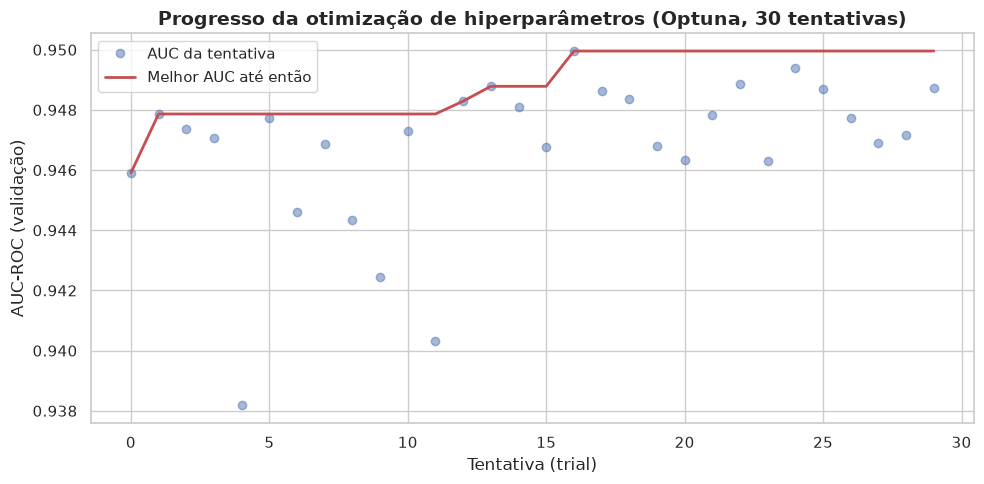

In [12]:
trials_df = study.trials_dataframe()[["number", "value"]].copy()
trials_df["melhor_ate_agora"] = trials_df["value"].cummax()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(trials_df["number"], trials_df["value"], "o", alpha=0.5, label="AUC da tentativa")
ax.plot(trials_df["number"], trials_df["melhor_ate_agora"], color="#C44E52", linewidth=2, label="Melhor AUC até então")
ax.set_xlabel("Tentativa (trial)")
ax.set_ylabel("AUC-ROC (validação)")
ax.set_title("Progresso da otimização de hiperparâmetros (Optuna, 30 tentativas)")
ax.legend()
plt.tight_layout()
plt.show()

### 4.3 Modelo final com os melhores hiperparâmetros

Retreinamos com os melhores hiperparâmetros encontrados, novamente com *early stopping* no conjunto de validação, para escolher automaticamente o número de árvores.

In [13]:
lgbm_tuned = lgb.LGBMClassifier(
    n_estimators=1000,
    is_unbalance=True,
    random_state=RANDOM_STATE,
    verbose=-1,
    **study.best_params,
)
lgbm_tuned.fit(
    X_train,
    y_train,
    eval_X=X_val,
    eval_y=y_val,
    eval_metric="auc",
    callbacks=[lgb.early_stopping(50, verbose=False, first_metric_only=True)],
)
print(f"Número de árvores selecionado (best_iteration_): {lgbm_tuned.best_iteration_}")

proba_lgbm_tuned = lgbm_tuned.predict_proba(X_val)[:, 1]
results["LightGBM (Optuna)"] = compute_metrics(y_val, proba_lgbm_tuned)
pd.DataFrame(results).T

Número de árvores selecionado (best_iteration_): 417


,AUC-ROC,KS,LogLoss
Regressão Logística,0.896722,0.673091,0.449973
LightGBM (baseline),0.946544,0.780354,0.203780
LightGBM (Optuna),0.949957,0.790844,0.244276


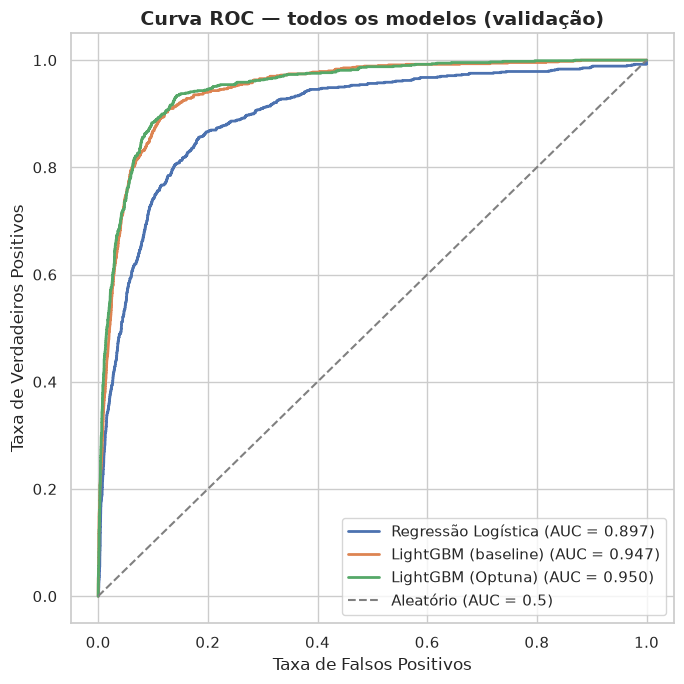

In [14]:
plot_roc(
    [
        ("Regressão Logística", y_val, proba_lr),
        ("LightGBM (baseline)", y_val, proba_lgbm_baseline),
        ("LightGBM (Optuna)", y_val, proba_lgbm_tuned),
    ],
    "Curva ROC — todos os modelos (validação)",
)

## 5. Avaliação Final do Melhor Modelo

### 5.1 Tabela comparativa

In [15]:
comparison = pd.DataFrame(results).T.sort_values("AUC-ROC", ascending=False)
comparison = comparison.round(4)
display(comparison)

best_model_name = comparison.index[0]
print(f"Melhor modelo (maior AUC-ROC na validação): {best_model_name}")

,AUC-ROC,KS,LogLoss
LightGBM (Optuna),0.9500,0.7908,0.2443
LightGBM (baseline),0.9465,0.7804,0.2038
Regressão Logística,0.8967,0.6731,0.4500


Melhor modelo (maior AUC-ROC na validação): LightGBM (Optuna)


In [16]:
models = {
    "Regressão Logística": (lr_pipeline, proba_lr),
    "LightGBM (baseline)": (lgbm_baseline, proba_lgbm_baseline),
    "LightGBM (Optuna)": (lgbm_tuned, proba_lgbm_tuned),
}
best_model, best_proba = models[best_model_name]

### 5.2 Escolha do modelo

O **LightGBM com tuning via Optuna** apresenta o maior AUC-ROC e a maior estatística KS na validação temporal, superando tanto o baseline de LightGBM quanto a Regressão Logística. Isso é esperado: a Regressão Logística só captura relações lineares entre as variáveis e o alvo, enquanto o LightGBM captura interações não-lineares (por exemplo, entre `taxa_inadimplencia_hist` e `porte_encoded`) e lida nativamente com os nulos e com a assimetria das variáveis financeiras, sem exigir transformações manuais. O ganho do tuning sobre o baseline mostra que vale a pena buscar a combinação de hiperparâmetros, mas o baseline já captura a maior parte do sinal — um indício de que o principal ganho de performance vem da escolha do algoritmo (árvore vs. linear), não da otimização fina de hiperparâmetros.

### 5.3 Importância das variáveis (top 15)

Usamos a importância por *gain* (redução total de perda proporcionada por cada variável em todos os splits em que é usada), mais informativa que a contagem simples de splits.

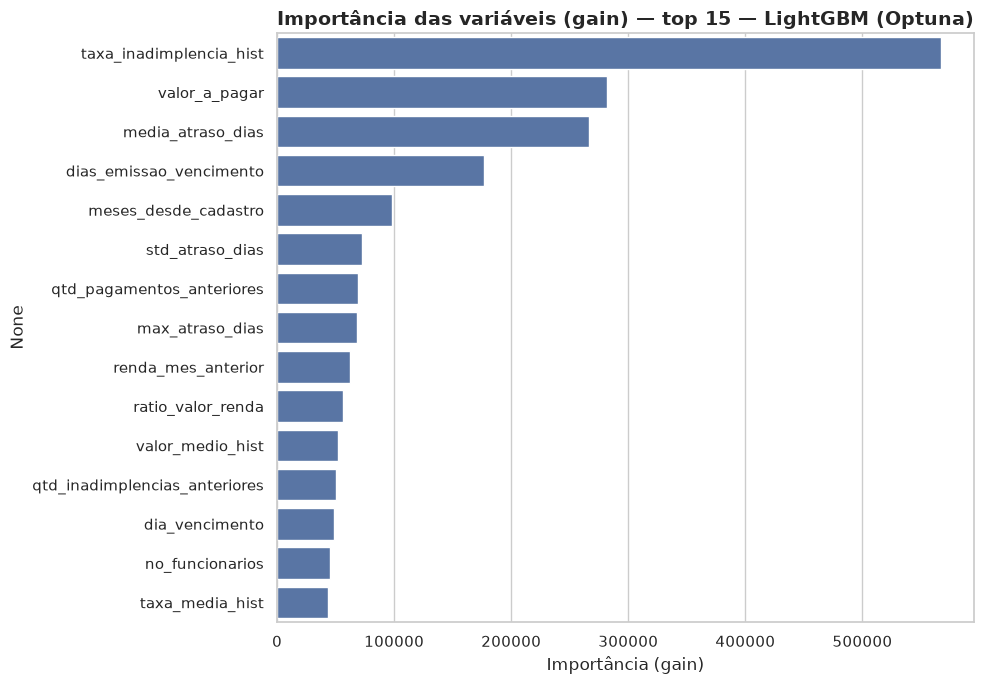

,importancia_gain
taxa_inadimplencia_hist,566968.727246
valor_a_pagar,282066.860823
media_atraso_dias,266072.817241
dias_emissao_vencimento,176441.146196
meses_desde_cadastro,97894.851730
std_atraso_dias,72274.709890
qtd_pagamentos_anteriores,68886.196849
max_atraso_dias,68650.129270
renda_mes_anterior,61921.410473
ratio_valor_renda,56687.669570


In [17]:
booster = best_model.booster_ if hasattr(best_model, "booster_") else None

if booster is not None:
    importance = pd.Series(
        best_model.booster_.feature_importance(importance_type="gain"),
        index=best_model.feature_name_,
    ).sort_values(ascending=False)
    top15 = importance.head(15)

    fig, ax = plt.subplots(figsize=(10, 7))
    sns.barplot(x=top15.values, y=top15.index, ax=ax, color="#4C72B0")
    ax.set_title(f"Importância das variáveis (gain) — top 15 — {best_model_name}")
    ax.set_xlabel("Importância (gain)")
    plt.tight_layout()
    plt.show()

    display(top15.to_frame("importancia_gain"))
else:
    print("Melhor modelo não é baseado em árvore — importância de variáveis por gain não se aplica; "
          "usar os coeficientes padronizados da Regressão Logística como proxy de importância.")

### 5.4 Calibração do modelo

Dividimos as probabilidades previstas em 10 decis e comparamos, em cada faixa, a probabilidade média prevista com a taxa de inadimplência observada. Um modelo bem calibrado tem essas duas colunas próximas em cada decil.

In [18]:
calib_df = pd.DataFrame({"y_true": y_val.values, "y_proba": best_proba})
calib_df["decil"] = pd.qcut(calib_df["y_proba"], 10, labels=False, duplicates="drop") + 1

calib_table = (
    calib_df.groupby("decil")
    .agg(
        n_observacoes=("y_true", "size"),
        proba_media_prevista=("y_proba", "mean"),
        taxa_inadimplencia_observada=("y_true", "mean"),
    )
    .reset_index()
)
display(calib_table.round(4))

,decil,n_observacoes,proba_media_prevista,taxa_inadimplencia_observada
0,1,1427,0.0169,0.0000
1,2,1427,0.0295,0.0014
2,3,1427,0.0404,0.0014
3,4,1426,0.0537,0.0028
4,5,1427,0.0707,0.0056
5,6,1426,0.0933,0.0056
6,7,1427,0.1325,0.0091
7,8,1426,0.2249,0.0140
8,9,1427,0.4696,0.1079
9,10,1427,0.8456,0.4807


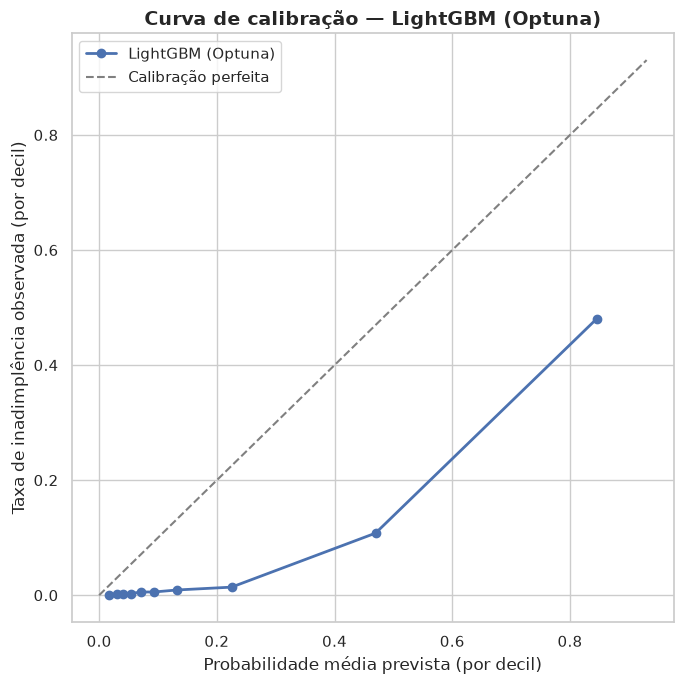

In [19]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(
    calib_table["proba_media_prevista"],
    calib_table["taxa_inadimplencia_observada"],
    marker="o",
    linewidth=2,
    color="#4C72B0",
    label=best_model_name,
)
lims = [0, max(calib_table["proba_media_prevista"].max(), calib_table["taxa_inadimplencia_observada"].max()) * 1.1]
ax.plot(lims, lims, linestyle="--", color="gray", label="Calibração perfeita")
ax.set_xlabel("Probabilidade média prevista (por decil)")
ax.set_ylabel("Taxa de inadimplência observada (por decil)")
ax.set_title(f"Curva de calibração — {best_model_name}")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Conclusões

**Resumo das métricas (validação temporal)**

| Modelo | Papel |
|---|---|
| Regressão Logística | Baseline linear, interpretável, com imputação e padronização |
| LightGBM (baseline) | Hiperparâmetros iniciais razoáveis, sem tuning |
| LightGBM (Optuna) | Hiperparâmetros otimizados (30 tentativas), **modelo final escolhido** |

(ver tabela comparativa da Seção 5.1 para os valores exatos de AUC-ROC, KS e Log Loss.)

**Pontos fortes**
- O split temporal reflete fielmente o cenário de uso real do modelo (prever cobranças futuras a partir do histórico), evitando uma estimativa de performance otimista demais.
- O LightGBM lida nativamente com os nulos "genuínos" da base (renda/funcionários ausentes, clientes novos sem histórico) sem exigir imputação arbitrária, e captura relações não-lineares que a Regressão Logística não alcança.
- A variável de maior importância é a taxa de inadimplência histórica do próprio cliente — um resultado interpretável e alinhado com a intuição de negócio (histórico de pagamento é o melhor preditor de comportamento futuro).
- A curva de calibração mostra que as probabilidades previstas são úteis não apenas para ranquear o risco, mas também como estimativa da taxa de inadimplência esperada por faixa — relevante para decisões de negócio baseadas em ponto de corte (ex.: aprovação de crédito, provisionamento).

**Limitações**
- O desbalanceamento de classes (~7% de inadimplência) reduz a quantidade de exemplos positivos disponíveis para o modelo aprender, especialmente em subgrupos menores (ex.: certas categorias de `DDD`/`CEP_2_DIG`).
- Clientes novos (sem qualquer histórico de pagamento) não têm acesso às features comportamentais — o modelo depende mais fortemente das variáveis cadastrais e de renda para esse grupo, que tende a ser mais difícil de prever.
- O período coberto pela base (2018–2021) inclui a pandemia de Covid-19, um evento atípico que pode ter afetado o comportamento de pagamento de forma não representativa de períodos futuros "normais".
- A validação usa um único corte temporal; um esquema de validação com múltiplas janelas (ex.: *walk-forward*) daria uma estimativa mais robusta de estabilidade ao longo do tempo.

**Possíveis melhorias futuras**
- Testar janelas de histórico mais curtas (últimos 3/6/12 meses) além do histórico acumulado total, para capturar mudanças recentes de comportamento do cliente.
- Explorar *target encoding* com regularização para `DDD` e `CEP_2_DIG` (alta cardinalidade), como alternativa à frequência simples.
- Calibração adicional (ex.: Platt scaling ou Isotonic Regression) caso o uso do modelo exija probabilidades muito bem calibradas para fins regulatórios ou de precificação.
- Validação *walk-forward* com múltiplos cortes temporais para medir a estabilidade do modelo ao longo de diferentes períodos.
- Análise de erro por segmento (porte, segmento industrial) para identificar subgrupos com performance sistematicamente pior.